<a href="https://colab.research.google.com/github/m1deey/Used_car_prediction/blob/main/01_exploring_feature_ing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [101]:
df=pd.read_csv("used_cars.csv")
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [47]:
print(df.describe())

        model_year
count  4009.000000
mean   2015.515590
std       6.104816
min    1974.000000
25%    2012.000000
50%    2017.000000
75%    2020.000000
max    2024.000000


In [48]:
print(df.isnull().sum())

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


In [49]:
print(df["fuel_type"].value_counts())

fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64


In [103]:
df["fuel_type"]=df["fuel_type"].fillna(df["fuel_type"].mode()[0])

In [51]:
print(df["accident"].value_counts())

accident
None reported                             2910
At least 1 accident or damage reported     986
Name: count, dtype: int64


In [85]:
df[df["accident"].isna()].head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
20,Genesis,GV70 3.5T Sport,2023,"5,400 mi.",Gasoline,375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Green,Beige,NaN,NaN,"$60,000"
89,Subaru,Forester 2.5 X,2004,"210,703 mi.",Gasoline,165.0HP 2.5L 4 Cylinder Engine Gasoline Fuel,M/T,Green,Beige,NaN,NaN,"$2,300"
128,Audi,Q7 3.0T Premium Plus,2015,"98,527 mi.",Gasoline,280.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Black,Black,NaN,NaN,"$9,995"
129,Lucid,Air Pure,2023,"1,300 mi.",Gasoline,620.0HP Electric Motor Electric Fuel System,A/T,Black,Gray,NaN,NaN,"$86,900"
131,Audi,TTS 2.0T Premium Plus,2012,"72,922 mi.",Gasoline,265.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Black,NaN,NaN,"$25,999"


In [104]:
df[["accident", "clean_title"]].value_counts(dropna=False)

,,count
accident,clean_title,
None reported,Yes,2468
At least 1 accident or damage reported,Yes,945
None reported,NaN,442
NaN,NaN,113
At least 1 accident or damage reported,NaN,41


In [105]:
df["accident"] = df["accident"].fillna("Unknown")

In [56]:
print(df["clean_title"].value_counts())

clean_title
Yes    3413
Name: count, dtype: int64


In [106]:
df["clean_title"] = df["clean_title"].fillna("Unknown")

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     4009 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      4009 non-null   object
 10  clean_title   4009 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [60]:
print(df["brand"].value_counts().head())

brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Name: count, dtype: int64


In [107]:
df = pd.get_dummies(df, columns=["brand"], dtype=int)

In [38]:
print(df["model"].value_counts())

model
M3 Base             30
F-150 XLT           24
Corvette Base       22
1500 Laramie        18
Camaro 2SS          17
                    ..
Mazda6 Signature     1
SLK-Class SLK320     1
Protege DX           1
Q5 40 Premium        1
Passat 2.5 SE        1
Name: count, Length: 1898, dtype: int64


In [108]:
df = pd.get_dummies(df, columns=["model"], dtype=int)

In [39]:
print(df["milage"].value_counts())

milage
110,000 mi.    16
45,000 mi.     15
120,000 mi.    13
55,000 mi.     13
54,000 mi.     12
               ..
40,900 mi.      1
74,150 mi.      1
94,448 mi.      1
34,967 mi.      1
10,950 mi.      1
Name: count, Length: 2818, dtype: int64


In [109]:
df["milage"] = (
    df["milage"]
    .str.replace(" mi.", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(int)
)

In [40]:
print(df["engine"].value_counts())

engine
2.0L I4 16V GDI DOHC Turbo                               52
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel             48
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel             47
–                                                        45
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel    44
                                                         ..
305.0HP 6.8L 10 Cylinder Engine Gasoline Fuel             1
562.0HP 5.2L 10 Cylinder Engine Gasoline Fuel             1
245.0HP 5.9L Straight 6 Cylinder Engine Diesel Fuel       1
303.0HP 3.7L V6 Cylinder Engine Gasoline Fuel             1
160.0HP 1.4L 4 Cylinder Engine Gasoline Fuel              1
Name: count, Length: 1146, dtype: int64


In [110]:
df["horsepower"] = df["engine"].str.extract(r"(\d+\.?\d*)HP").astype(float)
df["engine_size"] = df["engine"].str.extract(r"(\d+\.?\d*)L").astype(float)
df["cylinders"] = (
    df["engine"]
    .str.extract(r"(\d+)\s*Cylinder|[VIH](\d+)")
    .bfill(axis=1)
    .iloc[:, 0]
    .astype(float)
)
df["turbo"] = df["engine"].str.contains("Turbo", case=False, na=False).astype(int)
df[["engine", "horsepower", "engine_size", "cylinders", "turbo"]].head()

,engine,horsepower,engine_size,cylinders,turbo
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,300.0,3.7,6.0,0
1,3.8L V6 24V GDI DOHC,NaN,3.8,6.0,0
2,3.5 Liter DOHC,NaN,NaN,NaN,0
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,354.0,3.5,6.0,0
4,2.0L I4 16V GDI DOHC Turbo,NaN,2.0,4.0,1


In [111]:
df[["horsepower", "engine_size", "cylinders"]].isna().sum()

,0
horsepower,808
engine_size,377
cylinders,424


In [112]:
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())
df["engine_size"] = df["engine_size"].fillna(df["engine_size"].median())
df["cylinders"] = df["cylinders"].fillna(df["cylinders"].median())

In [113]:
df.drop(columns=["engine"], inplace=True)

In [41]:
print(df["transmission"].value_counts())

transmission
A/T                                  1037
8-Speed A/T                           406
Transmission w/Dual Shift Mode        398
6-Speed A/T                           362
6-Speed M/T                           248
                                     ... 
10-Speed Automatic with Overdrive       1
9-Speed Automatic with Auto-Shift       1
SCHEDULED FOR OR IN PRODUCTION          1
6 Speed Mt                              1
8-Speed Manual                          1
Name: count, Length: 62, dtype: int64


In [114]:
def simplify_transmission(x):
    x = str(x).lower()

    if "cvt" in x:
        return "CVT"
    elif "manual" in x or "m/t" in x:
        return "Manual"
    elif "dual" in x or "dct" in x:
        return "Dual Clutch"
    elif "automatic" in x or "a/t" in x:
        return "Automatic"
    else:
        return "Other"

df["transmission"] = df["transmission"].apply(simplify_transmission)

In [115]:
df = pd.get_dummies(df, columns=["transmission"], dtype=int)

In [42]:
print(df["ext_col"].value_counts())

ext_col
Black                         905
White                         816
Gray                          496
Silver                        374
Blue                          349
                             ... 
Pristine White                  1
Garnet Red Metallic             1
Cayenne Red Tintcoat            1
Pink                            1
Brands Hatch Gray Metallic      1
Name: count, Length: 319, dtype: int64


In [43]:
print(df["int_col"].value_counts())

int_col
Black                   2025
Beige                    538
Gray                     472
Brown                    157
–                        133
                        ... 
Gray w/Blue Bolsters       1
Very Light Cashmere        1
Black / Gray               1
Deep Chestnut              1
Black / Graphite           1
Name: count, Length: 156, dtype: int64


In [116]:
top_colors = ["Black", "White", "Gray", "Silver", "Blue", "Red"]

df["ext_col"] = df["ext_col"].apply(lambda x: x if x in top_colors else "Other")
df["int_col"] = df["int_col"].apply(lambda x: x if x in top_colors else "Other")
df = pd.get_dummies(df, columns=["ext_col", "int_col"], dtype=int)

In [117]:
df["model_age"]=df["model_year"].max()-df["model_year"]
df = df.drop("model_year", axis=1)

In [118]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(int)
)
df["price"].dtype

dtype('int64')

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

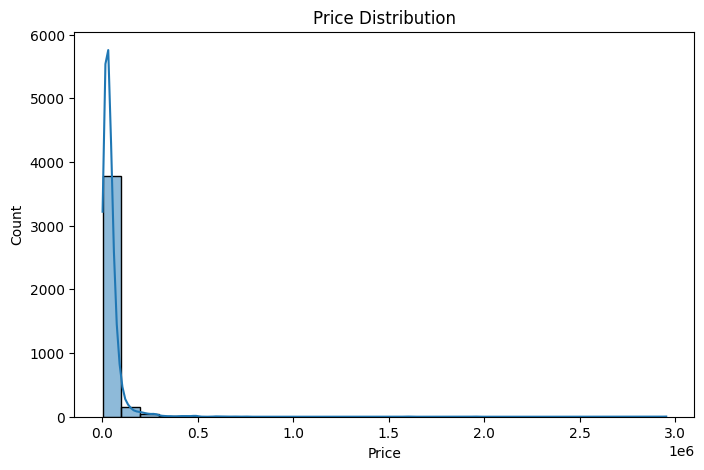

In [126]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

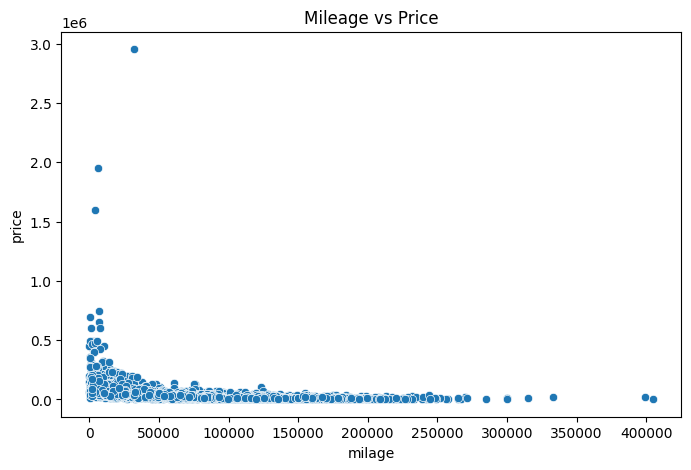

In [127]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="milage", y="price", data=df)
plt.title("Mileage vs Price")
plt.show()

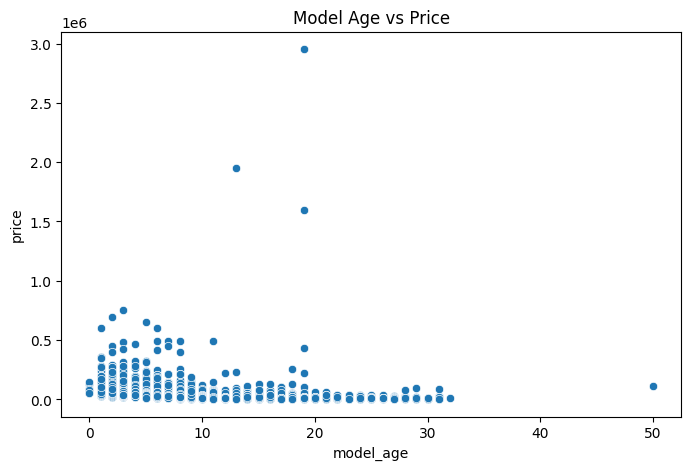

In [128]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="model_age", y="price", data=df)
plt.title("Model Age vs Price")
plt.show()

In [131]:
df = df[df["model_age"] <= 40]

## Results

The data was successfully cleaned and prepared for regression. Exploratory analysis showed that mileage and model age are negatively correlated with price. The dataset is now ready for training and evaluating machine learning regression models.